In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import numpy as np

In [20]:
df_desmatamento = pd.read_csv("../2.dados/PRODES/desmatamento_municipal/base_desmatamento_por_municipio_e_ano.csv")
df_desmatamento = df_desmatamento[['nome_municipio', 'area_desmatada', 'codigo_municipio', 'uf', 'ano']]
df_desmatamento.columns = ['nome_municipio', 'area_desmatada', 'codigo_municipio_ibge', 'nome_uf', 'ano']
df_desmatamento.head()

,nome_municipio,area_desmatada,codigo_municipio_ibge,nome_uf,ano
0,Peixoto de Azevedo,69.19,5106422,Mato Grosso,2008
1,Pau D'Arco,10.78,1505551,Pará,2008
2,Mâncio Lima,4.31,1200336,Acre,2008
3,Alto Alegre,36.39,1400050,Roraima,2008
4,Pedra Preta,0.00,5106372,Mato Grosso,2008


In [21]:
df_malaria = pd.read_csv("../2.dados/malaria/dados_malaria.csv")
df_malaria = df_malaria.sort_values(by=['codigo_municipio_ibge', 'ano'])
df_malaria['incremento_malaria'] = df_malaria.groupby('codigo_municipio_ibge')['valor'].diff()
df_malaria.head()

,Unnamed: 0,codigo_municipio_ibge,municipio,nome_uf,ano,valor,incremento_malaria
550,550,1100015,Alta Floresta D'Oeste,Rondônia,2008,210.0,NaN
1205,1205,1100015,Alta Floresta D'Oeste,Rondônia,2009,79.0,-131.0
1860,1860,1100015,Alta Floresta D'Oeste,Rondônia,2010,41.0,-38.0
2515,2515,1100015,Alta Floresta D'Oeste,Rondônia,2011,17.0,-24.0
3170,3170,1100015,Alta Floresta D'Oeste,Rondônia,2012,36.0,19.0


In [22]:
df_merged = pd.merge(df_malaria, df_desmatamento, on=['codigo_municipio_ibge', 'ano', 'nome_uf'], how='outer')
df_merged = df_merged[['codigo_municipio_ibge', 'municipio', 'ano', 'valor','nome_uf', 'area_desmatada']]
df_merged[['valor', 'area_desmatada']] = df_merged[['valor', 'area_desmatada']].fillna(value=0)
df_merged.columns = ['codigo_municipio', 'nome_municipio', 'ano', 'quantidade_casos','uf', 'area_desmatada_km2']
df_merged

,codigo_municipio,nome_municipio,ano,quantidade_casos,uf,area_desmatada_km2
0,1100015,Alta Floresta D'Oeste,2008,210.0,Rondônia,26.29
1,1100015,Alta Floresta D'Oeste,2009,79.0,Rondônia,5.04
2,1100015,Alta Floresta D'Oeste,2010,41.0,Rondônia,1.78
3,1100015,Alta Floresta D'Oeste,2011,17.0,Rondônia,6.81
4,1100015,Alta Floresta D'Oeste,2012,36.0,Rondônia,5.26
...,...,...,...,...,...,...
12747,5108956,Nova Monte Verde,2019,0.0,Mato Grosso,40.03
12748,5108956,Nova Monte Verde,2020,0.0,Mato Grosso,18.89
12749,5108956,Nova Monte Verde,2021,0.0,Mato Grosso,26.11
12750,5108956,Nova Monte Verde,2022,0.0,Mato Grosso,34.26


In [23]:
df_merged = df_merged.sort_values(by=["codigo_municipio", "ano"])
df_merged["desmatamento_ano_anterior"] = df_merged.groupby("codigo_municipio")["area_desmatada_km2"].shift(1)
df_merged

,codigo_municipio,nome_municipio,ano,quantidade_casos,uf,area_desmatada_km2,desmatamento_ano_anterior
0,1100015,Alta Floresta D'Oeste,2008,210.0,Rondônia,26.29,NaN
1,1100015,Alta Floresta D'Oeste,2009,79.0,Rondônia,5.04,26.29
2,1100015,Alta Floresta D'Oeste,2010,41.0,Rondônia,1.78,5.04
3,1100015,Alta Floresta D'Oeste,2011,17.0,Rondônia,6.81,1.78
4,1100015,Alta Floresta D'Oeste,2012,36.0,Rondônia,5.26,6.81
...,...,...,...,...,...,...,...
12747,5108956,Nova Monte Verde,2019,0.0,Mato Grosso,40.03,16.81
12748,5108956,Nova Monte Verde,2020,0.0,Mato Grosso,18.89,40.03
12749,5108956,Nova Monte Verde,2021,0.0,Mato Grosso,26.11,18.89
12750,5108956,Nova Monte Verde,2022,0.0,Mato Grosso,34.26,26.11


In [33]:
df_consolidado = df_merged.groupby(['codigo_municipio', 'nome_municipio','uf']).agg({
    'area_desmatada_km2': 'sum',
    'quantidade_casos': 'sum'
}).reset_index()

In [39]:
df_consolidado['area_desmatada_km2'].min()

0.0

In [42]:
df_consolidado.sort_values("quantidade_casos", ascending=False).head(10)['quantidade_casos'].min()

67773.0

In [25]:
gdf = gpd.read_file("../2.dados/ibge_malha_municipal/BR_Municipios_2024.shp")
estados_amazonia = ['AC', 'AM', 'AP', 'MA', 'MT', 'PA', 'RO', 'RR', 'TO']
gdf_amazonia = gdf[gdf['SIGLA_UF'].isin(estados_amazonia)].copy()
gdf_amazonia["codigo_municipio"] = gdf_amazonia["CD_MUN"].astype(int)

### Mapa quartil por intensidade

/var/folders/gy/cxx2_pv95ys52g0qvnjgcsqm0000gn/T/ipykernel_8678/2797123589.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  contornos_estados['centroide'] = contornos_estados.geometry.centroid


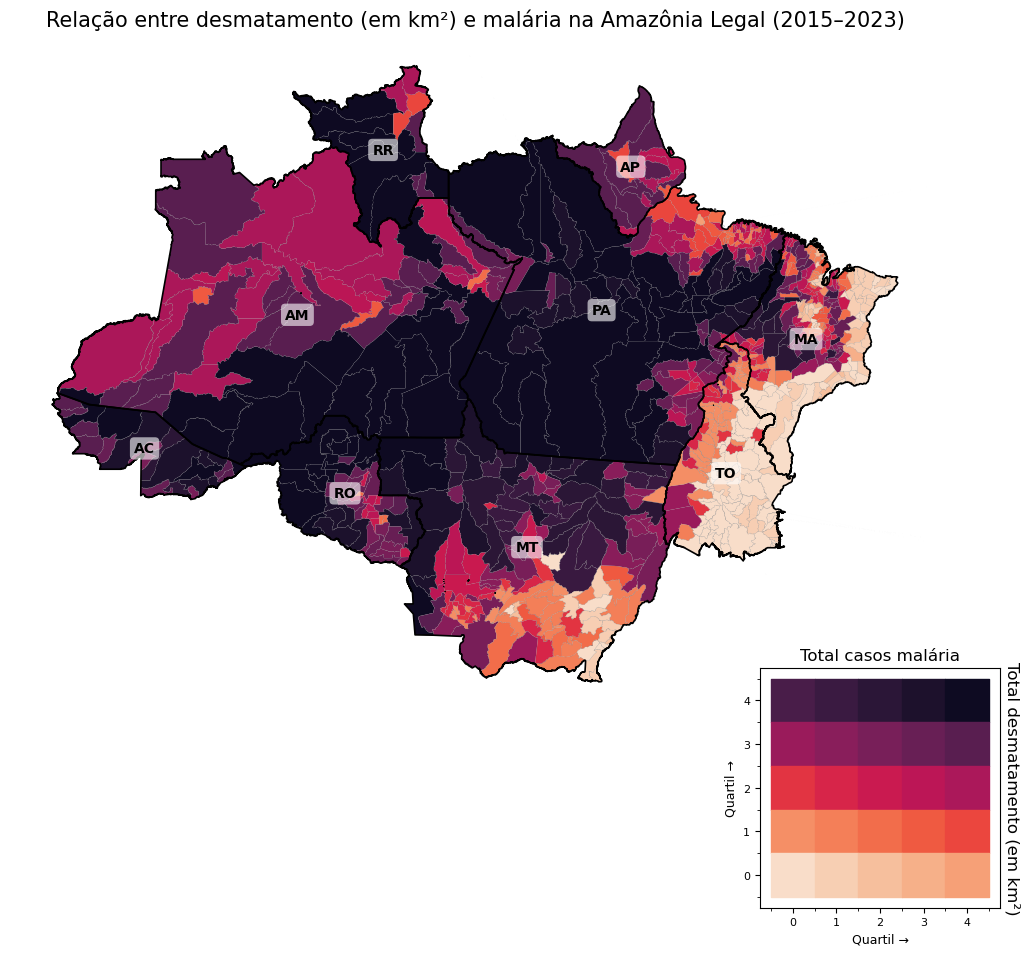

In [26]:
mapa = gdf_amazonia.merge(df_consolidado, on='codigo_municipio', how='outer')

mapa.loc[~mapa['area_desmatada_km2'].eq(0) & mapa['area_desmatada_km2'].notna(), 'desmat_quartil'] = pd.qcut(
    mapa.loc[~mapa['area_desmatada_km2'].eq(0) & mapa['area_desmatada_km2'].notna(), 'area_desmatada_km2'],
    4,
    labels=[1, 2, 3, 4]
)

mapa['desmat_quartil'] = mapa['desmat_quartil'].cat.add_categories(0)
mapa.loc[mapa['area_desmatada_km2'].eq(0) | mapa['area_desmatada_km2'].isna(), 'desmat_quartil'] = 0

mapa.loc[~mapa['quantidade_casos'].eq(0) & mapa['quantidade_casos'].notna(), 'malaria_quartil'] = pd.qcut(
    mapa.loc[~mapa['quantidade_casos'].eq(0) & mapa['quantidade_casos'].notna(), 'quantidade_casos'],
    4,
    labels=[1, 2, 3, 4]
)

mapa['malaria_quartil'] = mapa['malaria_quartil'].cat.add_categories(0)
mapa.loc[mapa['quantidade_casos'].eq(0) | mapa['quantidade_casos'].isna(), 'malaria_quartil'] = 0

mapa['desmat_quartil'] = mapa['desmat_quartil'].astype(int)
mapa['malaria_quartil'] = mapa['malaria_quartil'].astype(int)
mapa['grupo'] = mapa['desmat_quartil'].astype(str) + '-' + mapa['malaria_quartil'].astype(str)

n = 5 

palette = sns.color_palette("rocket_r", n_colors=n * n)  
palette = np.array(palette)
palette = palette.reshape((n, n, 3))
cores = {}
for i in range(n):
    for j in range(n):
        key = f"{i}-{j}"
        r, g, b = palette[i, j]  
        hex_color = '#%02x%02x%02x' % (int(r * 255), int(g * 255), int(b * 255))
        cores[key] = hex_color

mapa['color'] = mapa['grupo'].map(cores).fillna('#f0f0f0')

fig, ax = plt.subplots(figsize=(12, 12))
mapa.plot(ax=ax, color=mapa['color'], linewidth=0.1, edgecolor='gray')

contornos_estados = gdf_amazonia.dissolve(by='SIGLA_UF')
contornos_estados.boundary.plot(ax=ax, linewidth=1.2, edgecolor='black')

contornos_estados['centroide'] = contornos_estados.geometry.centroid
for idx, row in contornos_estados.iterrows():
    x = row['centroide'].x
    y = row['centroide'].y
    ax.text(
        x, y, idx,
        fontsize=10, fontweight='bold',
        ha='center', va='center',
        color='black',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.3')
    )

ax.set_title('Relação entre desmatamento (em km²) e malária na Amazônia Legal (2015–2023)', fontsize=15)
ax.axis('off')

axins = fig.add_axes([0.75, 0.05, 0.2, 0.2])

for i in range(n):
    for j in range(n):
        axins.fill_between([j, j + 1], i, i + 1, color=palette[4 - i, j])

axins.set_xticks(np.arange(n) + 0.5)
axins.set_xticklabels([str(i) for i in range(n)], fontsize=8)
axins.set_yticks(np.arange(n) + 0.5)
axins.set_yticklabels([str(i) for i in reversed(range(n))], fontsize=8)
axins.invert_yaxis()

axins.set_xticks(np.arange(n + 1), minor=True)
axins.set_yticks(np.arange(n + 1), minor=True)
axins.grid(False)

#axins.set_title('Legenda\n(Heatmap)', fontsize=10)

axins.set_ylabel('Quartil →', fontsize=9)
axins.set_xlabel('Quartil →', fontsize=9)

axins.text(
    2.5, -0.7,  
    'Total casos malária',
    ha='center',va='top',
    fontsize=12
)

axins.text(
    5.7, 2.5,  
    'Total desmatamento (em km²)',
    ha='right', va='center',
    fontsize=12, 
    rotation=270
)

plt.show()


### Mapa de desmatamento

/var/folders/gy/cxx2_pv95ys52g0qvnjgcsqm0000gn/T/ipykernel_8678/449720662.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_desmat = cm.get_cmap('YlOrRd')
/var/folders/gy/cxx2_pv95ys52g0qvnjgcsqm0000gn/T/ipykernel_8678/449720662.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_malaria = cm.get_cmap('Reds')
/var/folders/gy/cxx2_pv95ys52g0qvnjgcsqm0000gn/T/ipykernel_8678/449720662.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  contornos_estados['centroide'] = contornos_estados.geometry.c

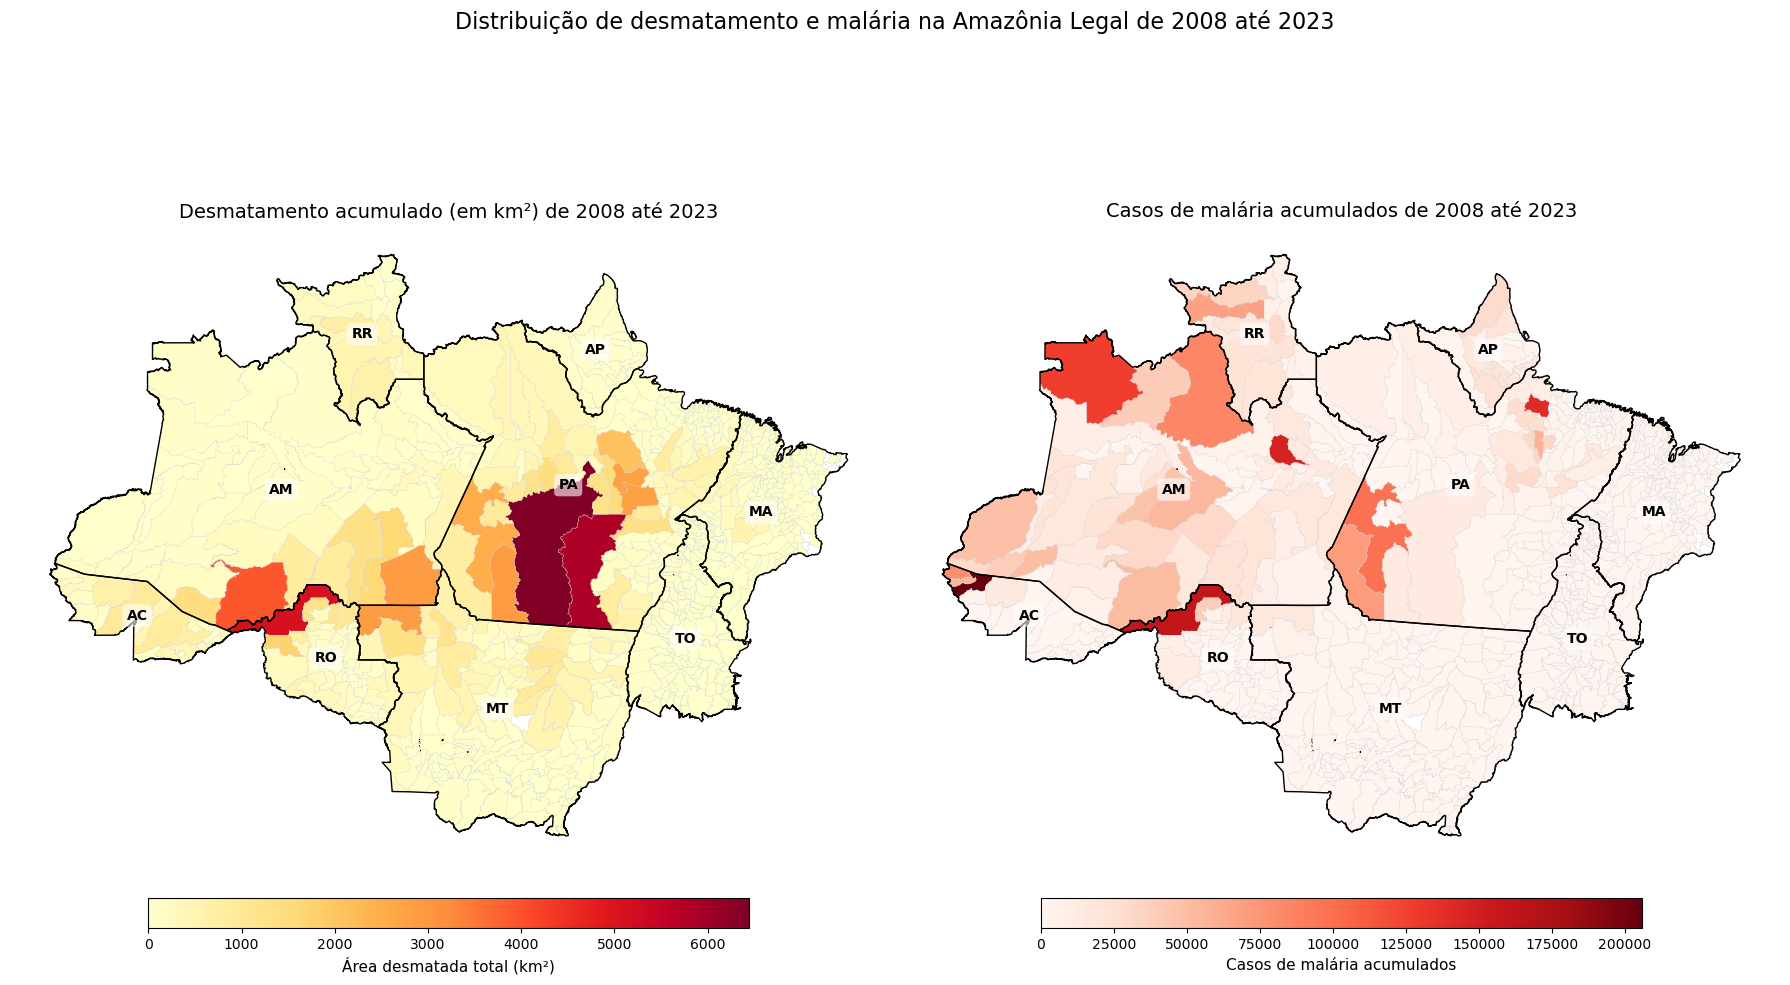

In [27]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from matplotlib.colors import Normalize
import matplotlib.cm as cm

norm_desmat = Normalize(
    vmin=mapa['area_desmatada_km2'].min(),
    vmax=mapa['area_desmatada_km2'].max()
)

norm_malaria = Normalize(
    vmin=mapa['quantidade_casos'].min(),
    vmax=mapa['quantidade_casos'].max()
)

cmap_desmat = cm.get_cmap('YlOrRd')
cmap_malaria = cm.get_cmap('Reds')

mapa['cor_desmat'] = mapa['area_desmatada_km2'].apply(
    lambda x: cmap_desmat(norm_desmat(x)) if pd.notnull(x) else (1, 1, 1, 0)
)
mapa['cor_malaria'] = mapa['quantidade_casos'].apply(
    lambda x: cmap_malaria(norm_malaria(x)) if pd.notnull(x) else (1, 1, 1, 0)
)

contornos_estados = gdf_amazonia.dissolve(by='SIGLA_UF')
contornos_estados['centroide'] = contornos_estados.geometry.centroid

fig, axs = plt.subplots(1, 2, figsize=(18, 10))

mapa.plot(ax=axs[0], color=mapa['cor_desmat'], edgecolor='lightgray', linewidth=0.2)
contornos_estados.boundary.plot(ax=axs[0], linewidth=1, edgecolor='black')
axs[0].set_title('Desmatamento acumulado (em km²) de 2008 até 2023', fontsize=14)
axs[0].axis('off')

mapa.plot(ax=axs[1], color=mapa['cor_malaria'], edgecolor='lightgray', linewidth=0.2)
contornos_estados.boundary.plot(ax=axs[1], linewidth=1, edgecolor='black')
axs[1].set_title('Casos de malária acumulados de 2008 até 2023', fontsize=14)
axs[1].axis('off')

for ax in axs:
    for idx, row in contornos_estados.iterrows():
        x = row['centroide'].x
        y = row['centroide'].y
        ax.text(
            x, y, idx,
            fontsize=10, fontweight='bold',
            ha='center', va='center',
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.3')
        )

sm1 = cm.ScalarMappable(cmap=cmap_desmat, norm=norm_desmat)
sm1.set_array([])
cbar1 = fig.colorbar(sm1, ax=axs[0], orientation='horizontal', fraction=0.036, pad=0.04)
cbar1.set_label('Área desmatada total (km²)', fontsize=11)

sm2 = cm.ScalarMappable(cmap=cmap_malaria, norm=norm_malaria)
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=axs[1], orientation='horizontal', fraction=0.036, pad=0.04)
cbar2.set_label('Casos de malária acumulados', fontsize=11)

plt.suptitle('Distribuição de desmatamento e malária na Amazônia Legal de 2008 até 2023', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
